# Motor Cortex Activity Analysis — Group 2 (Glove)
**Visualizations:**
1. **Topoplot of MAV features** — spatial distribution of signal amplitude during MI vs Rest
2. **Frequency spectrum (color bands)** — power in delta/theta/mu/beta/gamma bands during MI vs Rest

In [13]:
# Install dependencies if needed
# !pip install pyxdf mne scipy numpy matplotlib

In [14]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.colorbar import ColorbarBase
import mne
import pyxdf
from scipy.signal import welch, butter, filtfilt
from scipy.ndimage import gaussian_filter1d

mne.set_log_level('WARNING')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

## Configuration

In [15]:
DATA_DIR = os.path.dirname(os.path.abspath('__file__'))  # same folder as notebook

# Use OFFLINE sessions (most complete, hardcoded timings)
# Change to None to process ALL sessions
SESSION_FILTER = 'OFFLINE'

# Trigger codes
MI_BEGIN    = 200
MI_END      = 220
REST_BEGIN  = 100
REST_END    = 120
TARGET_MARKERS = [100, 120, 200, 220]

# Epoch window: t=0 is marker timestamp; baseline [-1, 0], analyze [0, 5]
T_PRE   = -1.0   # seconds before marker (for baseline)
T_POST  =  5.0   # seconds after marker
BASELINE = (-1.0, 0.0)

# Channels to drop
NON_EEG = {'AUX1', 'AUX2', 'AUX3', 'AUX7', 'AUX8', 'AUX9', 'TRIGGER'}

# MNE channel name rename (XDF uses uppercase, MNE standard_1020 uses mixed case)
RENAME = {
    'FP1': 'Fp1', 'FPZ': 'Fpz', 'FP2': 'Fp2',
    'FZ':  'Fz',  'CZ':  'Cz',  'PZ':  'Pz',
    'POZ': 'POz', 'OZ':  'Oz'
}

# Frequency bands for spectrum plot
BANDS = {
    'Delta\n(0.5–4 Hz)':  (0.5,  4,  '#4B6FA5'),
    'Theta\n(4–8 Hz)':    (4,    8,  '#5BA85B'),
    'Mu/Alpha\n(8–13 Hz)':(8,   13,  '#C07B3A'),
    'Beta\n(13–30 Hz)':   (13,  30,  '#A855A8'),
    'Gamma\n(30–50 Hz)':  (30,  50,  '#CC4444'),
}

## Helper Functions

In [16]:
def get_channel_names_from_xdf(eeg_stream):
    """Extract channel names from XDF stream metadata."""
    ch_desc = eeg_stream['info']['desc'][0]
    channels = ch_desc.get('channels', [{}])[0].get('channel', [])
    return [ch['label'][0] for ch in channels]


def load_xdf_file(filepath):
    """
    Load one XDF file and return:
      eeg_data      : (n_eeg_channels, n_samples) float64
      eeg_timestamps: (n_samples,)
      marker_data   : (n_markers,) int  — marker codes
      marker_ts     : (n_markers,) float — marker timestamps
      channel_names : list[str]
      sfreq         : float
    """
    streams, _ = pyxdf.load_xdf(filepath)

    eeg_stream = marker_stream = None
    for s in streams:
        stype = s['info']['type'][0].lower()
        if stype == 'eeg':
            eeg_stream = s
        elif stype == 'markers':
            marker_stream = s

    if eeg_stream is None or marker_stream is None:
        # Fallback: first stream is EEG, second is markers
        eeg_stream    = streams[0]
        marker_stream = streams[1] if len(streams) > 1 else None

    # EEG
    eeg_timestamps = np.array(eeg_stream['time_stamps'])
    eeg_data       = np.array(eeg_stream['time_series']).T   # (n_channels, n_samples)
    channel_names  = get_channel_names_from_xdf(eeg_stream)
    sfreq          = float(eeg_stream['info']['nominal_srate'][0])

    # Drop non-EEG channels
    valid_idx   = [i for i, ch in enumerate(channel_names) if ch not in NON_EEG]
    channel_names = [channel_names[i] for i in valid_idx]
    eeg_data      = eeg_data[valid_idx, :]

    # Rename for MNE montage compatibility
    channel_names = [RENAME.get(ch, ch) for ch in channel_names]

    # Markers
    marker_data = np.array([int(m[0])     for m in marker_stream['time_series']])
    marker_ts   = np.array([float(v[1])   for v in marker_stream['time_series']])

    # Keep only target markers
    keep = np.isin(marker_data, TARGET_MARKERS)
    marker_data = marker_data[keep]
    marker_ts   = marker_ts[keep]

    return eeg_data, eeg_timestamps, marker_data, marker_ts, channel_names, sfreq


def extract_epochs(eeg_data, eeg_ts, marker_data, marker_ts, sfreq,
                   begin_code, end_code, t_pre=T_PRE, t_post=T_POST):
    """
    Epoch EEG around BEGIN markers, ending at the paired END marker.
    Returns list of arrays: each (n_channels, epoch_samples).
    """
    epochs = []
    n_pre  = int(abs(t_pre)  * sfreq)
    n_post = int(t_post * sfreq)

    begin_idxs = np.where(marker_data == begin_code)[0]

    for bi in begin_idxs:
        t_start = marker_ts[bi]

        # Find the paired end marker
        future = np.where((marker_data == end_code) & (marker_ts > t_start))[0]
        if len(future) == 0:
            continue
        t_end = marker_ts[future[0]]

        # EEG sample indices
        i0 = np.searchsorted(eeg_ts, t_start + t_pre)
        i1 = np.searchsorted(eeg_ts, t_start + t_post)

        if i0 < 0 or i1 > eeg_data.shape[1]:
            continue

        epoch = eeg_data[:, i0:i1].copy()

        # Baseline correction: subtract mean of baseline window [t_pre, 0]
        n_baseline = int(abs(t_pre) * sfreq)
        if epoch.shape[1] > n_baseline:
            baseline_mean = epoch[:, :n_baseline].mean(axis=1, keepdims=True)
            epoch -= baseline_mean

        epochs.append(epoch)

    return epochs


def bandpass(data, lo, hi, sfreq, order=4):
    nyq = sfreq / 2.0
    lo  = max(lo, 0.5)          # avoid 0 Hz
    hi  = min(hi, nyq - 0.1)
    b, a = butter(order, [lo / nyq, hi / nyq], btype='band')
    return filtfilt(b, a, data, axis=-1)

## Load Data

In [17]:
xdf_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.xdf')))

if SESSION_FILTER:
    xdf_files = [f for f in xdf_files if SESSION_FILTER in os.path.basename(f)]

print(f'Found {len(xdf_files)} file(s) to process:')
for f in xdf_files:
    print(' ', os.path.basename(f))

all_mi_epochs   = []   # list of (n_channels, n_samples) arrays
all_rest_epochs = []
channel_names_global = None
sfreq_global         = None

for filepath in xdf_files:
    print(f'\nLoading {os.path.basename(filepath)} ...', end=' ', flush=True)
    try:
        eeg_data, eeg_ts, marker_data, marker_ts, ch_names, sfreq = load_xdf_file(filepath)
    except Exception as e:
        print(f'ERROR: {e}')
        continue

    if channel_names_global is None:
        channel_names_global = ch_names
        sfreq_global         = sfreq

    mi_epochs   = extract_epochs(eeg_data, eeg_ts, marker_data, marker_ts, sfreq,
                                 MI_BEGIN, MI_END)
    rest_epochs = extract_epochs(eeg_data, eeg_ts, marker_data, marker_ts, sfreq,
                                 REST_BEGIN, REST_END)

    all_mi_epochs.extend(mi_epochs)
    all_rest_epochs.extend(rest_epochs)
    print(f'{len(mi_epochs)} MI, {len(rest_epochs)} REST epochs')

print(f'\nTotal: {len(all_mi_epochs)} MI epochs, {len(all_rest_epochs)} REST epochs')
print(f'Channels ({len(channel_names_global)}): {channel_names_global}')
print(f'Sampling rate: {sfreq_global} Hz')

Found 6 file(s) to process:
  sub-S26CLASS_SUBJ_003_ses-S001OFFLINE_FES_task-Default_run-001_eeg.xdf
  sub-S26CLASS_SUBJ_003_ses-S004OFFLINE_NOFES_task-Default_run-001_eeg.xdf
  sub-S26CLASS_SUBJ_005_ses-S001OFFLINE_FES_task-Default_run-001_eeg.xdf
  sub-S26CLASS_SUBJ_005_ses-S004OFFLINE_NOFES_task-Default_run-001_eeg.xdf
  sub-S26CLASS_SUBJ_009_ses-S001OFFLINE_FES_task-Default_run-001_eeg.xdf
  sub-S26CLASS_SUBJ_009_ses-S004OFFLINE_NOFES_task-Default_run-001_eeg.xdf

Loading sub-S26CLASS_SUBJ_003_ses-S001OFFLINE_FES_task-Default_run-001_eeg.xdf ... 45 MI, 45 REST epochs

Loading sub-S26CLASS_SUBJ_003_ses-S004OFFLINE_NOFES_task-Default_run-001_eeg.xdf ... 45 MI, 45 REST epochs

Loading sub-S26CLASS_SUBJ_005_ses-S001OFFLINE_FES_task-Default_run-001_eeg.xdf ... 45 MI, 45 REST epochs

Loading sub-S26CLASS_SUBJ_005_ses-S004OFFLINE_NOFES_task-Default_run-001_eeg.xdf ... 45 MI, 45 REST epochs

Loading sub-S26CLASS_SUBJ_009_ses-S001OFFLINE_FES_task-Default_run-001_eeg.xdf ... 45 MI, 45 REST e

## Set Up MNE Montage

In [18]:
montage = mne.channels.make_standard_montage('standard_1020')
montage_ch_names = [ch.lower() for ch in montage.ch_names]

# Keep only channels that exist in the standard montage
valid_ch = [ch for ch in channel_names_global
            if ch.lower() in montage_ch_names]

# Indices into the epoch arrays
valid_idx = [channel_names_global.index(ch) for ch in valid_ch]

print(f'Channels with known montage positions ({len(valid_ch)}): {valid_ch}')

# Build MNE Info object for plotting
info = mne.create_info(ch_names=valid_ch, sfreq=sfreq_global, ch_types='eeg')
info.set_montage(montage)

Channels with known montage positions (32): ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2']


<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, M1, T7, ...
 chs: 32 EEG
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: unspecified
 nchan: 32
 projs: []
 sfreq: 512.0 Hz
>

## Compute MAV per Channel

In [19]:
def compute_mav(epochs, valid_idx, n_pre_samples):
    """
    Mean Absolute Value averaged over the active window [0, T_POST]
    (i.e., after the baseline portion).
    Returns: (n_valid_channels,)
    """
    mavs = []
    for ep in epochs:
        active = ep[valid_idx, n_pre_samples:]   # drop baseline
        mavs.append(np.mean(np.abs(active), axis=1))
    return np.mean(mavs, axis=0)   # average across trials


n_pre = int(abs(T_PRE) * sfreq_global)

mav_mi   = compute_mav(all_mi_epochs,   valid_idx, n_pre)
mav_rest = compute_mav(all_rest_epochs, valid_idx, n_pre)

# scale = 1.0  → data is already in µV
# scale = 1e6  → data is in Volts (raw from amp)
# The MAV values below will reveal which: if mean is ~1–100 µV it's already µV
scale = 1.0
mav_mi   *= scale
mav_rest *= scale

# Difference map: MI − Rest  (positive = more active during MI)
mav_diff = mav_mi - mav_rest

print('MAV (µV) summary:')
print(f'  MI   — mean: {mav_mi.mean():.3f}  range: [{mav_mi.min():.3f}, {mav_mi.max():.3f}]')
print(f'  REST — mean: {mav_rest.mean():.3f}  range: [{mav_rest.min():.3f}, {mav_rest.max():.3f}]')
print()
print('If values are ~1e6x too large, change scale = 1.0 → scale = 1e-6 (data may be in nV).')
print('If values are ~1e-6x too small, change scale = 1.0 → scale = 1e6 (data may be in V).')

MAV (µV) summary:
  MI   — mean: 33.034  range: [15.140, 87.473]
  REST — mean: 32.833  range: [15.077, 67.931]

If values are ~1e6x too large, change scale = 1.0 → scale = 1e-6 (data may be in nV).
If values are ~1e-6x too small, change scale = 1.0 → scale = 1e6 (data may be in V).


---
## Figure 1 — Topoplots of MAV Features (Motor Cortex Activity)

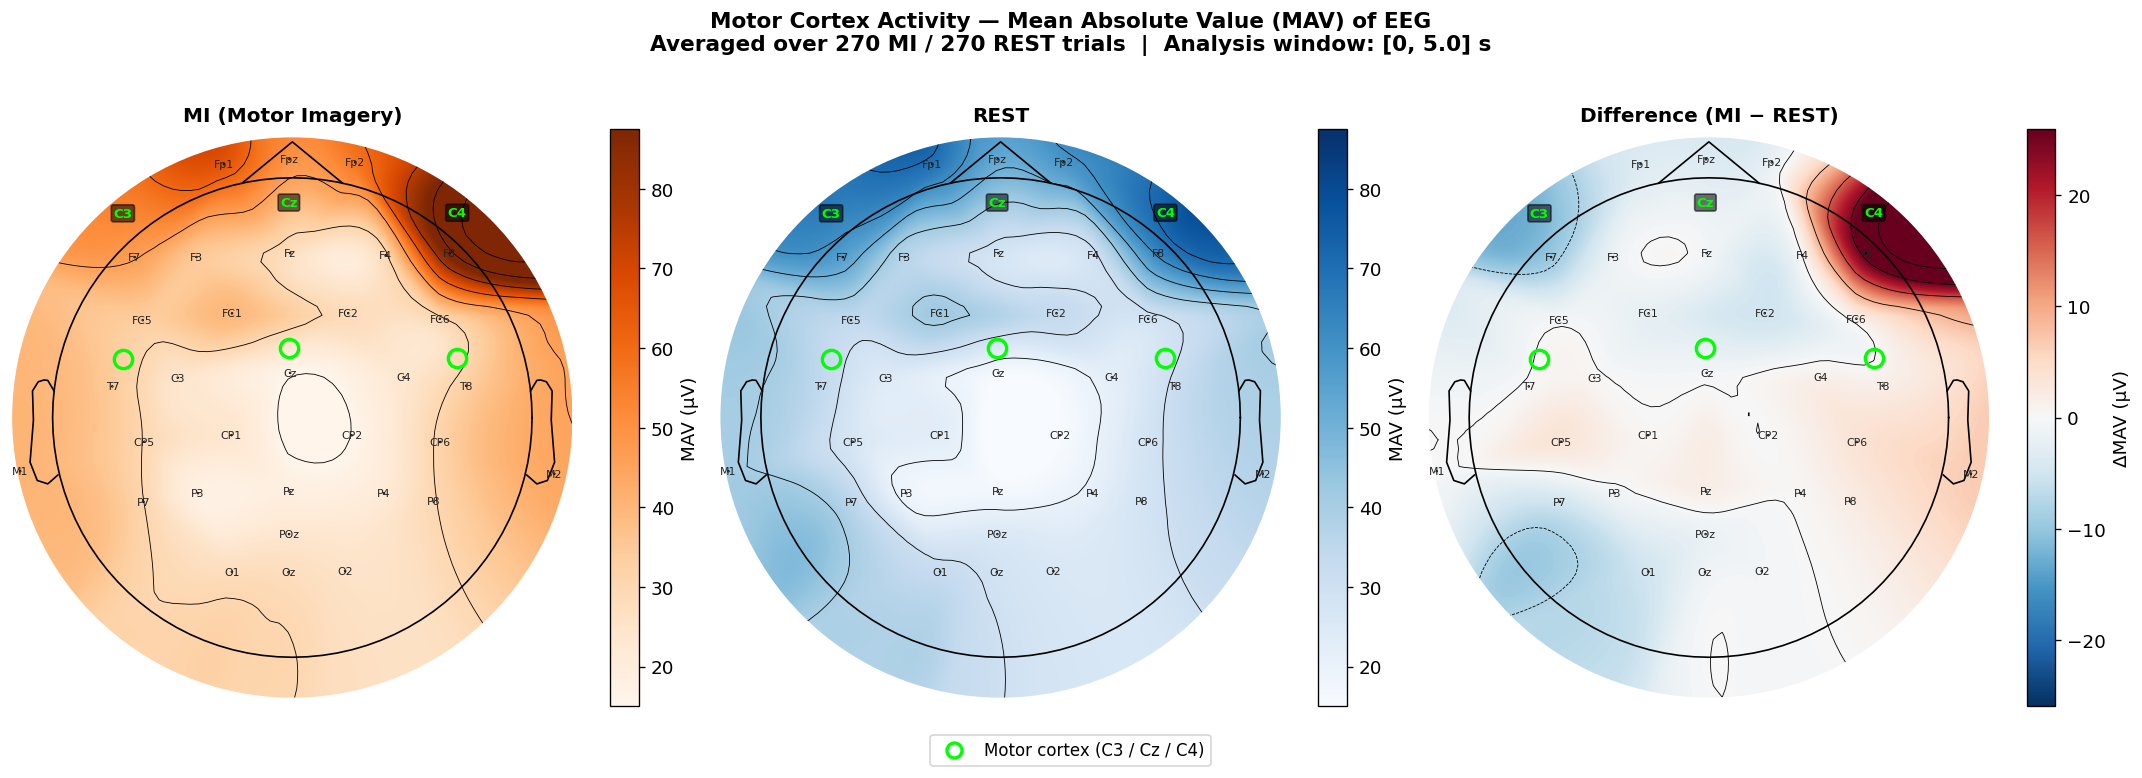

Saved: topoplot_MAV.png


In [20]:
MOTOR_CH = ['C3', 'Cz', 'C4']   # channels to highlight

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Motor Cortex Activity — Mean Absolute Value (MAV) of EEG\n'
             f'Averaged over {len(all_mi_epochs)} MI / {len(all_rest_epochs)} REST trials  |  '
             f'Analysis window: [0, {T_POST}] s',
             fontsize=13, fontweight='bold', y=1.02)

vmin_abs = min(mav_mi.min(), mav_rest.min())
vmax_abs = max(mav_mi.max(), mav_rest.max())

plots = [
    (mav_mi,   'MI (Motor Imagery)',     'Oranges',  vmin_abs, vmax_abs),
    (mav_rest, 'REST',                   'Blues',    vmin_abs, vmax_abs),
    (mav_diff, 'Difference (MI − REST)', 'RdBu_r',
     -np.abs(mav_diff).max(), np.abs(mav_diff).max()),
]

for ax, (data, title, cmap, vmin, vmax) in zip(axes, plots):
    im, cn = mne.viz.plot_topomap(
        data, info,
        axes=ax,
        cmap=cmap,
        vlim=(vmin, vmax),
        show=False,
        contours=6,
        sensors=True,       # draw all sensor dots
        names=valid_ch,     # label every electrode
    )
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.06,
                 label='MAV (µV)' if 'Diff' not in title else 'ΔMAV (µV)')

    # ── Shrink the auto-generated name texts so they don't overlap ──────────
    for txt in ax.texts:
        txt.set_fontsize(6.5)
        txt.set_color('#222222')

    # ── Overlay larger, coloured markers for motor cortex channels ──────────
    pos_dict = {ch: info['chs'][i]['loc'][:2]
                for i, ch in enumerate(valid_ch)}

    for ch in MOTOR_CH:
        if ch not in pos_dict:
            continue
        x_ch, y_ch = pos_dict[ch]
        # bright ring so it stands out against the heatmap
        ax.plot(x_ch, y_ch, 'o',
                markersize=11, markerfacecolor='none',
                markeredgecolor='lime', markeredgewidth=2.0,
                zorder=10)
        ax.text(x_ch, y_ch + 0.055, ch,
                ha='center', va='bottom', fontsize=8,
                fontweight='bold', color='lime',
                bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.55),
                zorder=11)

# Legend for the highlight
from matplotlib.lines import Line2D
legend_el = [Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
                    markeredgecolor='lime', markeredgewidth=2, markersize=9,
                    label='Motor cortex (C3 / Cz / C4)')]
fig.legend(handles=legend_el, loc='lower center', ncol=1,
           fontsize=10, framealpha=0.8, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('topoplot_MAV.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: topoplot_MAV.png')

---
## Figure 2 — Frequency Composition During MI vs REST

In [21]:
# ── Compute PSD (Welch) for each epoch, then average ──────────────────────────

def epochs_to_psd(epochs, valid_idx, n_pre, sfreq):
    """
    Compute PSD for the active window of each epoch.
    Returns: freqs (F,), psd_mean (n_channels, F), psd_sem (n_channels, F)
    """
    psds = []
    for ep in epochs:
        active = ep[valid_idx, n_pre:]          # (n_ch, n_active_samples)
        f, p = welch(active, fs=sfreq,
                     nperseg=min(int(sfreq * 2), active.shape[1]),
                     noverlap=int(sfreq),
                     window='hann', axis=-1)
        psds.append(p)                          # (n_ch, F)
    psds = np.array(psds)                       # (n_trials, n_ch, F)
    return f, psds.mean(axis=0), psds.std(axis=0) / np.sqrt(len(psds))


freqs, psd_mi_ch,   sem_mi_ch   = epochs_to_psd(all_mi_epochs,   valid_idx, n_pre, sfreq_global)
freqs, psd_rest_ch, sem_rest_ch = epochs_to_psd(all_rest_epochs, valid_idx, n_pre, sfreq_global)

# Average across all valid channels (or choose motor channels below)
motor_ch_names = ['C3', 'Cz', 'C4']   # primary motor cortex channels
motor_idx = [valid_ch.index(ch) for ch in motor_ch_names if ch in valid_ch]
if len(motor_idx) == 0:
    motor_idx = list(range(len(valid_ch)))   # fallback: all channels
    motor_label = 'All channels'
else:
    motor_label = 'Motor cortex: ' + ', '.join([valid_ch[i] for i in motor_idx])

psd_mi   = psd_mi_ch[motor_idx, :].mean(axis=0)
psd_rest = psd_rest_ch[motor_idx, :].mean(axis=0)
sem_mi   = sem_mi_ch[motor_idx, :].mean(axis=0)
sem_rest = sem_rest_ch[motor_idx, :].mean(axis=0)

# Restrict to 0.5–50 Hz for display
freq_mask = (freqs >= 0.5) & (freqs <= 50)
f_plot     = freqs[freq_mask]
psd_mi_p   = psd_mi[freq_mask]
psd_rest_p = psd_rest[freq_mask]
sem_mi_p   = sem_mi[freq_mask]
sem_rest_p = sem_rest[freq_mask]

# Convert to dB
psd_mi_db   = 10 * np.log10(psd_mi_p   + 1e-30)
psd_rest_db = 10 * np.log10(psd_rest_p + 1e-30)
sem_mi_db   = 10 * np.log10(np.maximum(psd_mi_p   - sem_mi_p,   1e-30) + 1e-30)
sem_rest_db = 10 * np.log10(np.maximum(psd_rest_p - sem_rest_p, 1e-30) + 1e-30)
err_mi   = psd_mi_db   - sem_mi_db
err_rest = psd_rest_db - sem_rest_db

print(f'PSD channels used: {motor_label}')

PSD channels used: Motor cortex: C3, Cz, C4


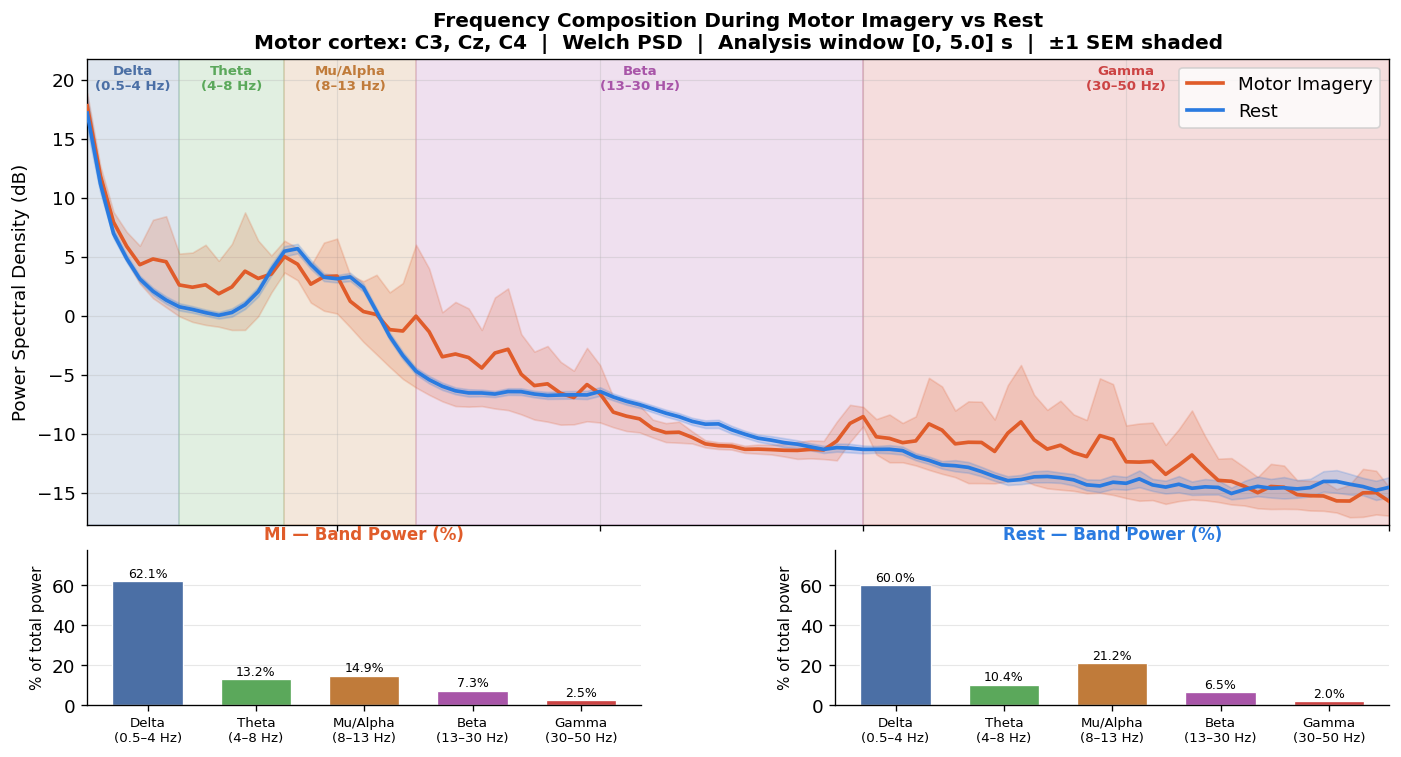

Saved: frequency_spectrum.png


In [22]:
# ── Plot ──────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 7))
gs  = GridSpec(2, 2, figure=fig, height_ratios=[3, 1], hspace=0.08, wspace=0.35)

ax_main = fig.add_subplot(gs[0, :])
ax_mi   = fig.add_subplot(gs[1, 0])
ax_rest = fig.add_subplot(gs[1, 1])

# ── Coloured frequency-band background ────────────────────────────────────────
y_min = min(psd_mi_db.min(), psd_rest_db.min()) - 2
y_max = max(psd_mi_db.max(), psd_rest_db.max()) + 4

for label, (lo, hi, color) in BANDS.items():
    lo_c = max(lo, f_plot[0])
    hi_c = min(hi, f_plot[-1])
    ax_main.axvspan(lo_c, hi_c, alpha=0.18, color=color, zorder=0)
    mid = (lo_c + hi_c) / 2
    ax_main.text(mid, y_max - 0.5, label, ha='center', va='top',
                 fontsize=8, color=color, fontweight='bold')

# ── PSD curves ────────────────────────────────────────────────────────────────
ax_main.plot(f_plot, psd_mi_db,   color='#E05C2A', lw=2.2, label='Motor Imagery', zorder=3)
ax_main.fill_between(f_plot,
                     psd_mi_db - err_mi,
                     psd_mi_db + err_mi,
                     color='#E05C2A', alpha=0.20, zorder=2)

ax_main.plot(f_plot, psd_rest_db, color='#2A7BE0', lw=2.2, label='Rest',          zorder=3)
ax_main.fill_between(f_plot,
                     psd_rest_db - err_rest,
                     psd_rest_db + err_rest,
                     color='#2A7BE0', alpha=0.20, zorder=2)

ax_main.set_xlim(f_plot[0], f_plot[-1])
ax_main.set_ylim(y_min, y_max)
ax_main.set_ylabel('Power Spectral Density (dB)', fontsize=11)
ax_main.set_xlabel('')
ax_main.set_xticklabels([])
ax_main.legend(fontsize=11, loc='upper right')
ax_main.set_title(
    f'Frequency Composition During Motor Imagery vs Rest\n'
    f'{motor_label}  |  Welch PSD  |  Analysis window [0, {T_POST}] s  |  ±1 SEM shaded',
    fontsize=12, fontweight='bold')
ax_main.grid(True, alpha=0.3, lw=0.7)

# ── Band power bar charts ─────────────────────────────────────────────────────

def band_power(f, psd, lo, hi):
    mask = (f >= lo) & (f < hi)
    if mask.sum() == 0:
        return 0.0
    return np.trapezoid(psd[mask], f[mask])


band_labels  = []
bp_mi_vals   = []
bp_rest_vals = []
bar_colors   = []

for label, (lo, hi, color) in BANDS.items():
    band_labels.append(label)
    bp_mi_vals.append(band_power(f_plot, psd_mi_p,   lo, hi))
    bp_rest_vals.append(band_power(f_plot, psd_rest_p, lo, hi))
    bar_colors.append(color)

# Normalise so bars show relative contribution (% of total power)
total_mi   = sum(bp_mi_vals)   + 1e-30
total_rest = sum(bp_rest_vals) + 1e-30
bp_mi_pct   = [v / total_mi   * 100 for v in bp_mi_vals]
bp_rest_pct = [v / total_rest * 100 for v in bp_rest_vals]

x = np.arange(len(band_labels))
w = 0.38

for ax, bp, title, line_color in [
    (ax_mi,   bp_mi_pct,   'MI — Band Power (%)',   '#E05C2A'),
    (ax_rest, bp_rest_pct, 'Rest — Band Power (%)', '#2A7BE0'),
]:
    bars = ax.bar(x, bp, width=0.65, color=bar_colors, edgecolor='white',
                  linewidth=0.8, zorder=2)
    for bar, val in zip(bars, bp):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(band_labels, fontsize=8)
    ax.set_ylabel('% of total power', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', color=line_color)
    ax.set_ylim(0, max(max(bp_mi_pct), max(bp_rest_pct)) * 1.25)
    ax.grid(axis='y', alpha=0.3, lw=0.7)
    ax.spines[['top', 'right']].set_visible(False)

plt.savefig('frequency_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: frequency_spectrum.png')

---
## Figure 3 — Per-Channel Topoplots for Each Frequency Band

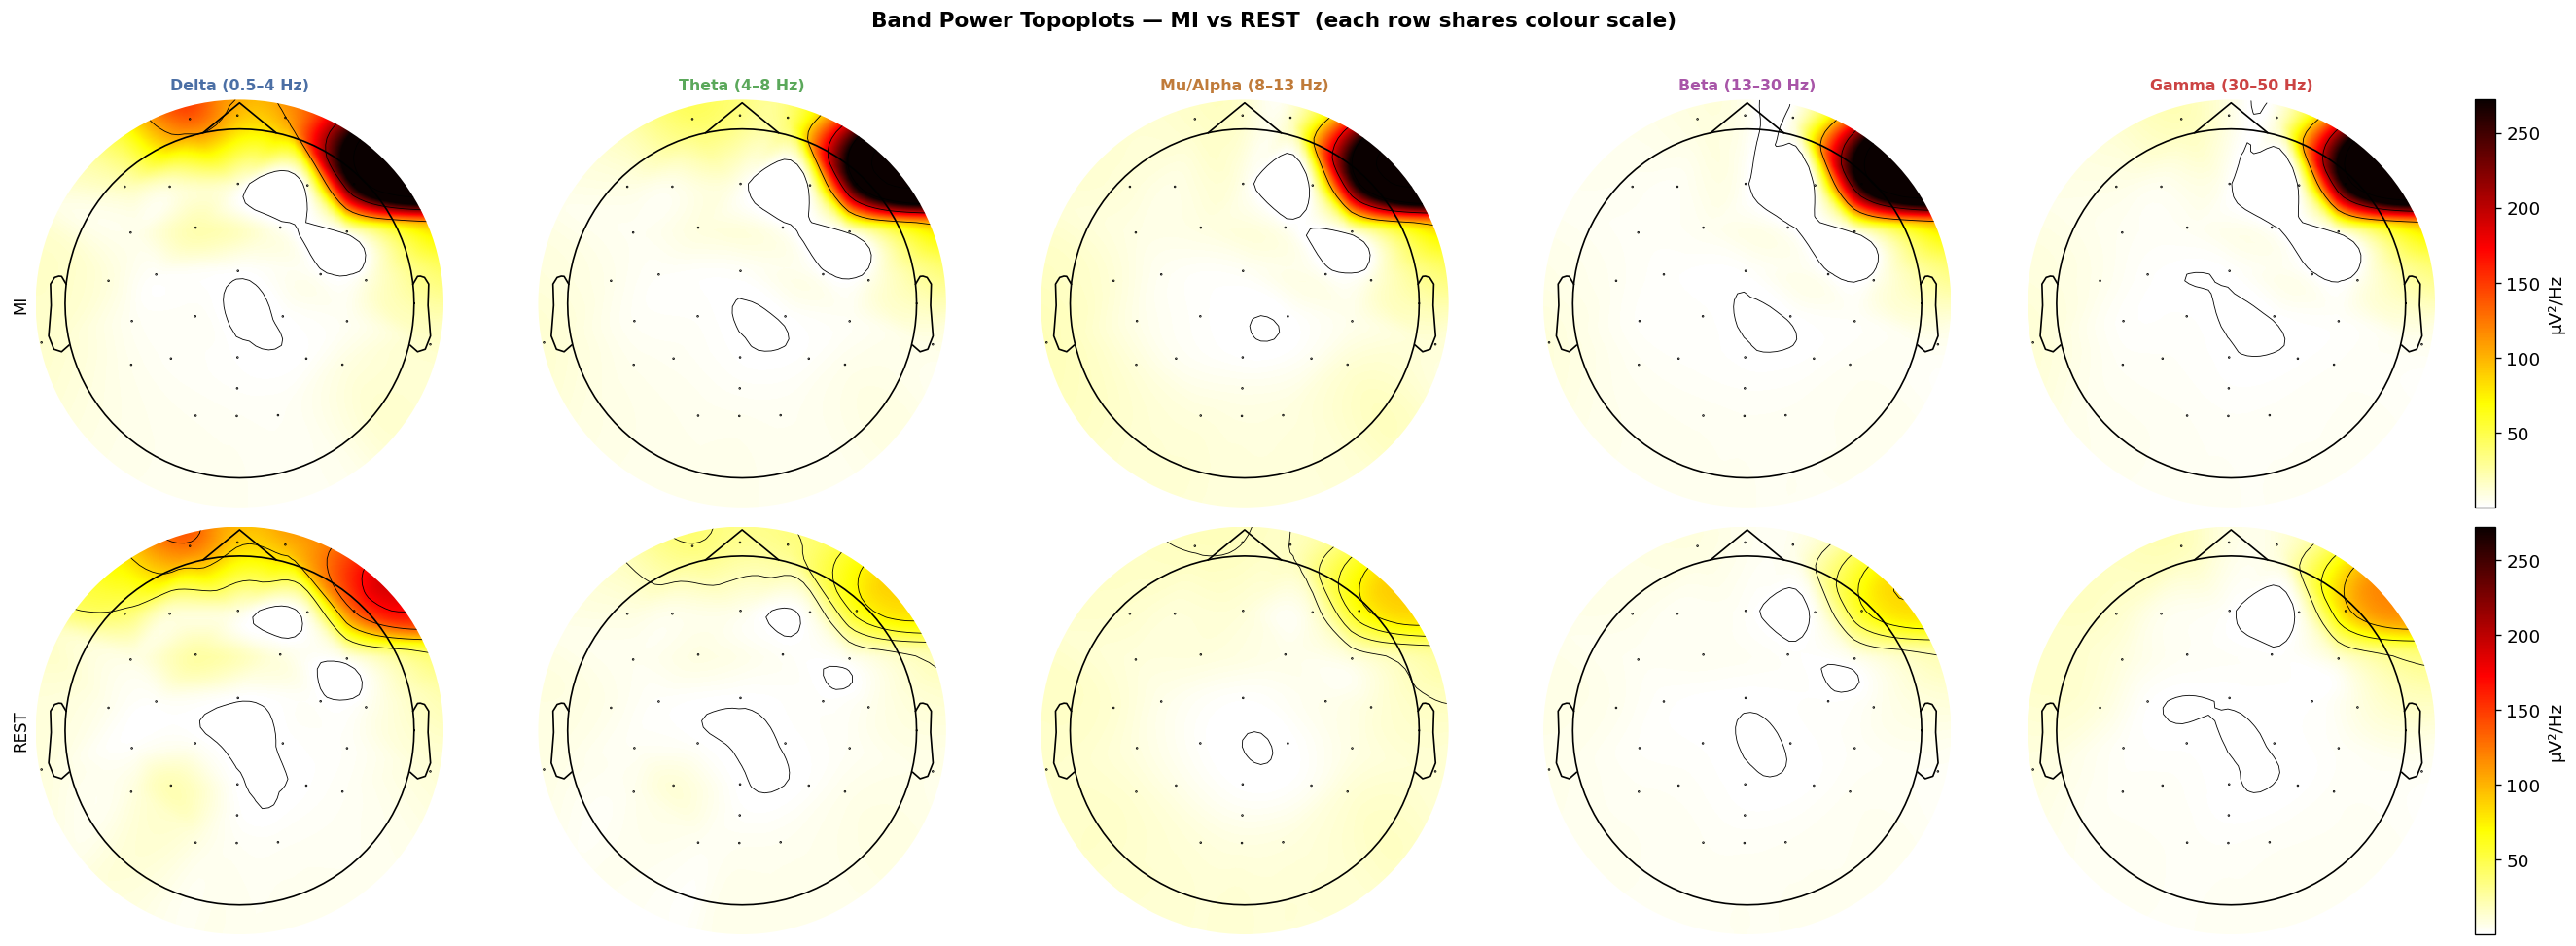

Saved: topoplot_band_power.png


In [23]:
# Band power per channel (used for band-specific topoplots)

def band_power_per_channel(epochs, valid_idx, n_pre, sfreq, lo, hi):
    """
    Returns mean band power (µV²/Hz integrated) per channel across epochs.
    Shape: (n_valid_channels,)
    """
    channel_bp = []
    for ep in epochs:
        active = ep[valid_idx, n_pre:]
        f, p = welch(active, fs=sfreq,
                     nperseg=min(int(sfreq * 2), active.shape[1]),
                     noverlap=int(sfreq), window='hann', axis=-1)
        mask = (f >= lo) & (f < hi)
        bp = np.trapezoid(p[:, mask], f[mask], axis=-1)   # (n_ch,)
        channel_bp.append(bp)
    return np.mean(channel_bp, axis=0)


n_bands = len(BANDS)
fig, axes = plt.subplots(2, n_bands, figsize=(4.5 * n_bands, 8))
fig.suptitle('Band Power Topoplots — MI vs REST  (each row shares colour scale)',
             fontsize=13, fontweight='bold', y=1.01)

row_labels = ['Motor Imagery', 'REST']
epoch_sets = [all_mi_epochs, all_rest_epochs]

for col, (band_label, (lo, hi, bcolor)) in enumerate(BANDS.items()):
    bp_mi_ch   = band_power_per_channel(all_mi_epochs,   valid_idx, n_pre, sfreq_global, lo, hi) * scale**2
    bp_rest_ch = band_power_per_channel(all_rest_epochs, valid_idx, n_pre, sfreq_global, lo, hi) * scale**2

    vmin = min(bp_mi_ch.min(), bp_rest_ch.min())
    vmax = max(bp_mi_ch.max(), bp_rest_ch.max())

    for row, (bp_ch, rlabel) in enumerate([(bp_mi_ch, 'MI'), (bp_rest_ch, 'REST')]):
        ax = axes[row, col]
        im, _ = mne.viz.plot_topomap(
            bp_ch, info, axes=ax,
            cmap='hot_r',
            vlim=(vmin, vmax),
            show=False, contours=4, sensors=True,
        )
        if row == 0:
            ax.set_title(band_label.replace('\n', ' '), fontsize=9.5,
                         fontweight='bold', color=bcolor)
        if col == 0:
            ax.set_ylabel(rlabel, fontsize=10)
        if col == n_bands - 1:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.08, label='µV²/Hz')

plt.tight_layout()
plt.savefig('topoplot_band_power.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: topoplot_band_power.png')

---
## Summary Statistics

In [24]:
print('=== Band Power Summary (motor channels: C3, Cz, C4) ===')
print(f'{"Band":<22} {"MI (µV²/Hz)":>14} {"REST (µV²/Hz)":>14} {"MI/REST ratio":>14}')
print('-' * 66)
for label, (lo, hi, _) in BANDS.items():
    bp_mi_m   = band_power_per_channel(all_mi_epochs,   valid_idx, n_pre, sfreq_global, lo, hi)
    bp_rest_m = band_power_per_channel(all_rest_epochs, valid_idx, n_pre, sfreq_global, lo, hi)
    m_mi   = bp_mi_m[motor_idx].mean()   * scale**2 if motor_idx else bp_mi_m.mean()   * scale**2
    m_rest = bp_rest_m[motor_idx].mean() * scale**2 if motor_idx else bp_rest_m.mean() * scale**2
    ratio  = m_mi / (m_rest + 1e-30)
    flag   = '  ← ERD/ERS' if abs(ratio - 1) > 0.1 else ''
    clean_label = label.replace('\n', ' ')
    print(f'{clean_label:<22} {m_mi:>14.4f} {m_rest:>14.4f} {ratio:>14.3f}{flag}')

print('\nERD = Event-Related Desynchronization (ratio < 1 → suppressed during MI)')
print('ERS = Event-Related Synchronization   (ratio > 1 → enhanced during MI)')

=== Band Power Summary (motor channels: C3, Cz, C4) ===
Band                      MI (µV²/Hz)  REST (µV²/Hz)  MI/REST ratio
------------------------------------------------------------------
Delta (0.5–4 Hz)              31.3986        25.8102          1.217  ← ERD/ERS
Theta (4–8 Hz)                 6.6702         4.4569          1.497  ← ERD/ERS
Mu/Alpha (8–13 Hz)             7.5159         9.0951          0.826  ← ERD/ERS
Beta (13–30 Hz)                3.7107         2.7744          1.337  ← ERD/ERS
Gamma (30–50 Hz)               1.2799         0.8454          1.514  ← ERD/ERS

ERD = Event-Related Desynchronization (ratio < 1 → suppressed during MI)
ERS = Event-Related Synchronization   (ratio > 1 → enhanced during MI)
